In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

%matplotlib inline
sns.set(style="whitegrid")  # 보기 좋은 테마
df = pd.read_csv("../data/creditcard.csv")  # 파일 경로 확인 필수

In [2]:
X = df.drop('Class', axis=1)
y = df['Class']


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=10000, class_weight='balanced')
model.fit(X_train, y_train)
joblib.dump(model, "../outputs/model_log.pkl")


['../outputs/model_log.pkl']

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # for AUC

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


[[55473  1391]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC AUC: 0.9718889789314713


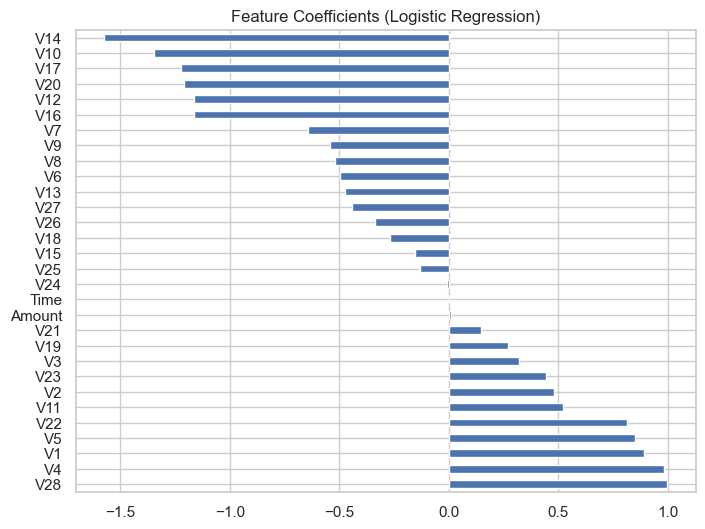

In [6]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values(ascending=False).plot(kind='barh', figsize=(8, 6))
plt.title("Feature Coefficients (Logistic Regression)")
plt.show()


In [7]:
## 🔹 2. Lasso 실험

In [8]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model_lasso = LogisticRegressionCV(
    Cs=3,
    cv=2,
    penalty='l1',
    solver='saga',
    scoring='roc_auc',
    class_weight='balanced',
    max_iter=5000,
    random_state=42,
    n_jobs=1  # 먼저 직렬로 확인
)

model_lasso.fit(X_train_scaled, y_train)
joblib.dump(model_lasso, "../outputs/model_lasso.pkl")


C:\Users\zxcvz\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\zxcvz\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\zxcvz\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


['../outputs/model_lasso.pkl']

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model_lasso.predict(X_test)
y_proba = model_lasso.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


[[56770    94]
 [   96     2]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.02      0.02      0.02        98

    accuracy                           1.00     56962
   macro avg       0.51      0.51      0.51     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC: 0.5108596020006202


C:\Users\zxcvz\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegressionCV was fitted without feature names
  warnings.warn(
C:\Users\zxcvz\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegressionCV was fitted without feature names
  warnings.warn(


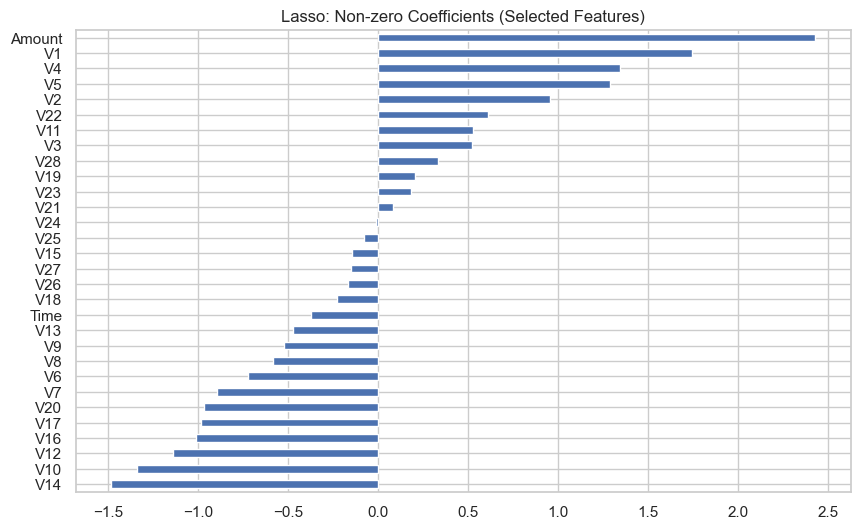

In [10]:
coef = pd.Series(model_lasso.coef_[0], index=X.columns)
non_zero = coef[coef != 0].sort_values()

non_zero.plot(kind='barh', figsize=(10, 6))
plt.title("Lasso: Non-zero Coefficients (Selected Features)")
plt.show()


In [11]:
joblib.dump((X_test, y_test), "../outputs/Xy_test.pkl")

['../outputs/Xy_test.pkl']